In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline 
sns.set(style="ticks")

Используем данные из 💥GPU Benchmarks Compilation📊

https://www.kaggle.com/datasets/alanjo/gpu-benchmarks?select=GPU_scores_graphicsAPIs.csv

In [72]:
data = pd.read_csv('GPU_benchmarks_v7.csv', sep=",")

In [73]:
# размер набора данных
data.shape

(2317, 9)

In [74]:
# типы колонок
data.dtypes

gpuName                 str
G3Dmark               int64
G2Dmark               int64
price               float64
gpuValue            float64
TDP                 float64
powerPerformance    float64
testDate              int64
category                str
dtype: object

In [75]:
# проверим есть ли пропущенные значения
data.isnull().sum()

gpuName                0
G3Dmark                0
G2Dmark                0
price               1764
gpuValue            1764
TDP                 1625
powerPerformance    1625
testDate               0
category               0
dtype: int64

In [76]:
# Первые 5 строк датасета
data.head()

,gpuName,G3Dmark,G2Dmark,price,gpuValue,TDP,powerPerformance,testDate,category
0,GeForce RTX 3090 Ti,29094,1117,2099.99,13.85,450.0,64.65,2022,Unknown
1,GeForce RTX 3080 Ti,26887,1031,1199.99,22.41,350.0,76.82,2021,Desktop
2,GeForce RTX 3090,26395,999,1749.99,15.08,350.0,75.41,2020,Desktop
3,Radeon RX 6900 XT,25458,1102,1120.31,22.72,300.0,84.86,2020,Desktop
4,GeForce RTX 3080,24853,1003,999.00,24.88,320.0,77.66,2020,Desktop


# Обработка пропусков в данных

In [77]:
# Удаление колонок, содержащих пустые значения
data_new_1 = data.dropna(axis=1, how='any')
(data.shape, data_new_1.shape)

((2317, 9), (2317, 5))

In [78]:
data_new_2 = data.dropna(axis=0, how='any')
(data.shape, data_new_2.shape)

((2317, 9), (387, 9))

In [79]:
total_count = data.shape[0]
# Выберем числовые колонки с пропущенными значениями
# Цикл по колонкам датасета
num_cols = []
for col in data.columns:
    # Количество пустых значений 
    temp_null_count = data[data[col].isnull()].shape[0]
    dt = str(data[col].dtype)
    if temp_null_count>0 and (dt=='float64' or dt=='int64'):
        num_cols.append(col)
        temp_perc = round((temp_null_count / total_count) * 100.0, 2)
        print('Колонка {}. Тип данных {}. Количество пустых значений {}, {}%.'.format(col, dt, temp_null_count, temp_perc))

Колонка price. Тип данных float64. Количество пустых значений 1764, 76.13%.
Колонка gpuValue. Тип данных float64. Количество пустых значений 1764, 76.13%.
Колонка TDP. Тип данных float64. Количество пустых значений 1625, 70.13%.
Колонка powerPerformance. Тип данных float64. Количество пустых значений 1625, 70.13%.


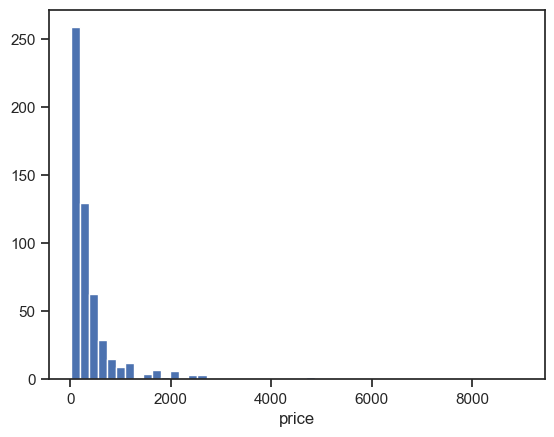

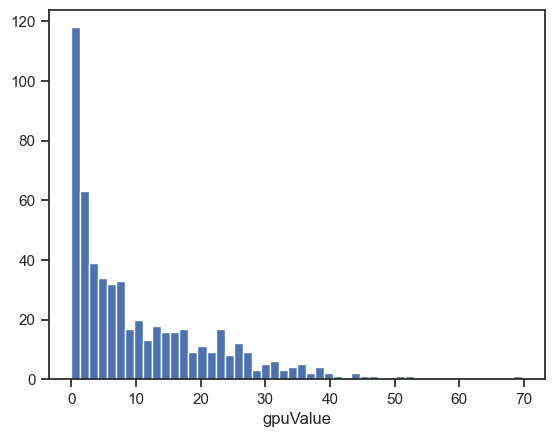

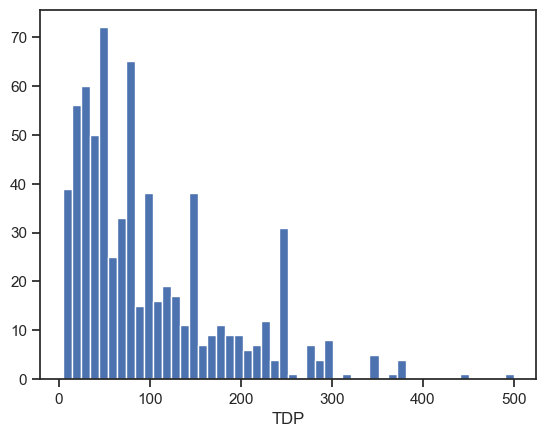

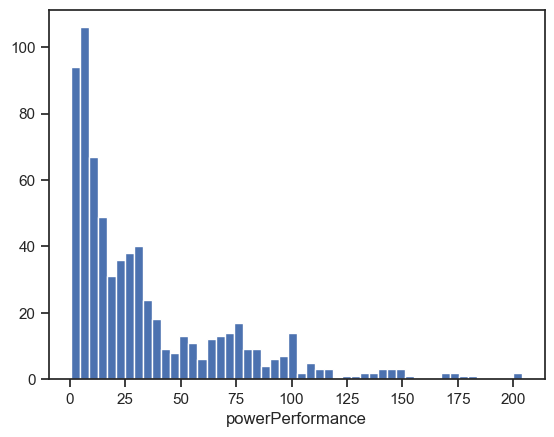

In [80]:
# Фильтр по колонкам с пропущенными значениями
data_num = data[num_cols]

# Гистограмма по признакам
for col in data_num:
    plt.hist(data[col], 50)
    plt.xlabel(col)
    plt.show()

In [81]:
from sklearn.impute import SimpleImputer
from sklearn.impute import MissingIndicator

strategies=['mean', 'median', 'most_frequent']

def test_num_impute_col(dataset, column, strategy_param):
    temp_data = dataset[[column]]
    
    indicator = MissingIndicator()
    mask_missing_values_only = indicator.fit_transform(temp_data)
    
    imp_num = SimpleImputer(strategy=strategy_param)
    data_num_imp = imp_num.fit_transform(temp_data)
    
    filled_data = data_num_imp[mask_missing_values_only]
    
    return column, strategy_param, filled_data.size, filled_data[0], filled_data[filled_data.size-1]

data[['price']].describe()

,price
count,553.00000
mean,439.74660
std,763.59252
min,17.50000
25%,109.99000
50%,209.00000
75%,435.00000
max,8999.00000


Варианты импьютации 

1. mean (среднее значение)

- распределение примерно нормальное

- нет сильных выбросов

- данные симметричны

2. median (медиана)

- распределение асимметричное

- есть перекос к маленьким или большим значениям

- есть выбросы

Поэтому опираясь на гистограммы используем:
- price -> median
- gpuValue -> median
- TDP -> mean
- powerPerformance -> median

In [82]:
print(test_num_impute_col(data, 'price', 'median'))
print(test_num_impute_col(data, 'gpuValue', 'median'))
print(test_num_impute_col(data, 'TDP', 'mean'))
print(test_num_impute_col(data, 'powerPerformance', 'median'))

('price', 'median', 1764, np.float64(209.0), np.float64(209.0))
('gpuValue', 'median', 1764, np.float64(6.58), np.float64(6.58))
('TDP', 'mean', 1625, np.float64(98.96806358381502), np.float64(98.96806358381502))
('powerPerformance', 'median', 1625, np.float64(20.825000000000003), np.float64(20.825000000000003))


In [83]:
def impute_and_apply(dataset, column, strategy):
    imp = SimpleImputer(strategy=strategy)
    dataset[column] = imp.fit_transform(dataset[[column]]).ravel()
    return dataset

In [84]:
impute_and_apply(data, 'price', 'median')
impute_and_apply(data, 'gpuValue', 'median')
impute_and_apply(data, 'TDP', 'mean')
impute_and_apply(data, 'powerPerformance', 'median')

,gpuName,G3Dmark,G2Dmark,price,gpuValue,TDP,powerPerformance,testDate,category
0,GeForce RTX 3090 Ti,29094,1117,2099.99,13.85,450.000000,64.650,2022,Unknown
1,GeForce RTX 3080 Ti,26887,1031,1199.99,22.41,350.000000,76.820,2021,Desktop
2,GeForce RTX 3090,26395,999,1749.99,15.08,350.000000,75.410,2020,Desktop
3,Radeon RX 6900 XT,25458,1102,1120.31,22.72,300.000000,84.860,2020,Desktop
4,GeForce RTX 3080,24853,1003,999.00,24.88,320.000000,77.660,2020,Desktop
...,...,...,...,...,...,...,...,...,...
2312,Intel 82852/82855 GM/GME Controller,1,107,209.00,6.58,98.968064,20.825,2010,Unknown
2313,Quadro2 Pro,1,143,209.00,6.58,98.968064,20.825,2009,Workstation
2314,Rage 128 Pro,1,40,209.00,6.58,98.968064,20.825,2009,Unknown
2315,RAGE 128 PRO AGP 4X TMDS,1,142,209.00,6.58,98.968064,20.825,2009,Unknown


In [85]:
data.isnull().sum()

gpuName             0
G3Dmark             0
G2Dmark             0
price               0
gpuValue            0
TDP                 0
powerPerformance    0
testDate            0
category            0
dtype: int64

In [86]:
# Первые 5 строк датасета
data.head()

,gpuName,G3Dmark,G2Dmark,price,gpuValue,TDP,powerPerformance,testDate,category
0,GeForce RTX 3090 Ti,29094,1117,2099.99,13.85,450.0,64.65,2022,Unknown
1,GeForce RTX 3080 Ti,26887,1031,1199.99,22.41,350.0,76.82,2021,Desktop
2,GeForce RTX 3090,26395,999,1749.99,15.08,350.0,75.41,2020,Desktop
3,Radeon RX 6900 XT,25458,1102,1120.31,22.72,300.0,84.86,2020,Desktop
4,GeForce RTX 3080,24853,1003,999.00,24.88,320.0,77.66,2020,Desktop


Кодирование категориальных признаков

In [89]:
data['category'] = data['category'].replace("Unknown", np.nan)
data['category'] = data['category'].replace("nan", np.nan)
data['category'] = data['category'].replace("NaN", np.nan)


In [39]:
# Выберем категориальные колонки с пропущенными значениями
# Цикл по колонкам датасета
cat_cols = []
for col in data.columns:
    # Количество пустых значений 
    temp_null_count = data[col].isnull().sum() + (data[col] == "Unknown").sum()
    dt = str(data[col].dtype)
    if temp_null_count>0 and (dt=='object' or dt=='str'):
        cat_cols.append(col)
        temp_perc = round((temp_null_count / total_count) * 100.0, 2)
        print('Колонка {}. Тип данных {}. Количество пустых значений {}, {}%.'.format(col, dt, temp_null_count, temp_perc))

Колонка category. Тип данных str. Количество пустых значений 1351, 58.31%.


Так как у нас категориальный признак, предпочтительно использовать наиболее частое значения для импьютации

In [90]:
print(test_num_impute_col(data, 'category', 'most_frequent'))

('category', 'most_frequent', 1351, 'Desktop', 'Desktop')


In [91]:
impute_and_apply(data, 'category', 'most_frequent')

,gpuName,G3Dmark,G2Dmark,price,gpuValue,TDP,powerPerformance,testDate,category
0,GeForce RTX 3090 Ti,29094,1117,2099.99,13.85,450.000000,64.650,2022,Desktop
1,GeForce RTX 3080 Ti,26887,1031,1199.99,22.41,350.000000,76.820,2021,Desktop
2,GeForce RTX 3090,26395,999,1749.99,15.08,350.000000,75.410,2020,Desktop
3,Radeon RX 6900 XT,25458,1102,1120.31,22.72,300.000000,84.860,2020,Desktop
4,GeForce RTX 3080,24853,1003,999.00,24.88,320.000000,77.660,2020,Desktop
...,...,...,...,...,...,...,...,...,...
2312,Intel 82852/82855 GM/GME Controller,1,107,209.00,6.58,98.968064,20.825,2010,Desktop
2313,Quadro2 Pro,1,143,209.00,6.58,98.968064,20.825,2009,Workstation
2314,Rage 128 Pro,1,40,209.00,6.58,98.968064,20.825,2009,Desktop
2315,RAGE 128 PRO AGP 4X TMDS,1,142,209.00,6.58,98.968064,20.825,2009,Desktop


Использование LabelEncoder

In [92]:
cat_temp_data = data[['category']]
cat_temp_data['category'].unique()

<StringArray>
['Desktop', 'Workstation', 'Mobile', 'Mobile, Workstation', 'Desktop, Mobile']
Length: 5, dtype: str

In [93]:
from sklearn.preprocessing import LabelEncoder
cat_enc = pd.DataFrame({'category': data['category']})
cat_enc



,category
0,Desktop
1,Desktop
2,Desktop
3,Desktop
4,Desktop
...,...
2312,Desktop
2313,Workstation
2314,Desktop
2315,Desktop


In [96]:
le = LabelEncoder()
cat_le = le.fit_transform(data['category'])
cat_le

array([0, 0, 0, ..., 0, 0, 0], shape=(2317,))

In [98]:
np.unique(cat_le)

array([0, 1, 2, 3, 4])

In [99]:
le.inverse_transform([0, 1, 2, 3, 4])

array(['Desktop', 'Desktop, Mobile', 'Mobile', 'Mobile, Workstation',
       'Workstation'], dtype=object)

# Масштабирование

In [100]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

cols_to_scale = ['G3Dmark', 'G2Dmark', 'price', 'gpuValue', 'TDP', 'powerPerformance', 'testDate']

data_scaled = data.copy()
data_scaled[cols_to_scale] = scaler.fit_transform(data[cols_to_scale])

In [102]:
data_scaled.head()

,gpuName,G3Dmark,G2Dmark,price,gpuValue,TDP,powerPerformance,testDate,category
0,GeForce RTX 3090 Ti,1.000000,1.000000,0.231864,0.198623,0.899112,0.314796,1.000000,Desktop
1,GeForce RTX 3080 Ti,0.924140,0.922523,0.131658,0.321382,0.697337,0.374637,0.923077,Desktop
2,GeForce RTX 3090,0.907229,0.893694,0.192895,0.216263,0.697337,0.367704,0.846154,Desktop
3,Radeon RX 6900 XT,0.875021,0.986486,0.122787,0.325828,0.596449,0.414171,0.846154,Desktop
4,GeForce RTX 3080,0.854226,0.897297,0.109280,0.356805,0.636804,0.378768,0.846154,Desktop
